In [1]:
%load_ext autoreload
%autoreload 2


In [2]:
%reload_ext autoreload
import csv
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# 1st real training

In [108]:
fp ="metrics/train/2025_12_12_0.csv"

df = pd.read_csv(fp)
df.head()

,epoch,batch,loss,rte
0,0,0,24971.986328,45.308849
1,0,1,46214.289062,58.956730
2,0,2,32598.015625,49.203766
3,0,3,24418.972656,38.694992
4,0,4,19000.382812,38.162357


In [109]:
df.loss[-500:].mean()

60.45634482383728

Text(0.5, 0, 'Iterations')

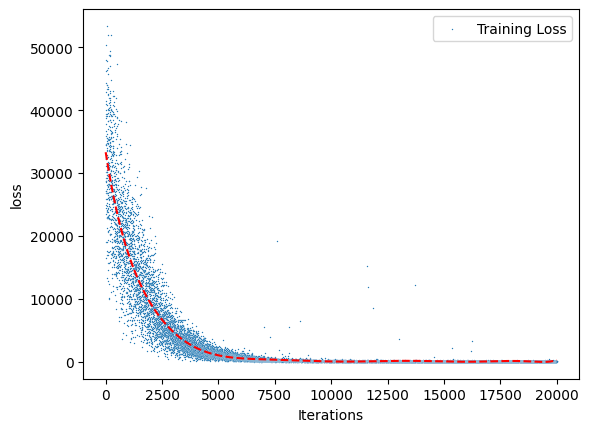

In [110]:
sns.scatterplot(data=df, x=df.index, y='loss', label='Training Loss', s=1)
# trend line
z = np.polyfit(df.index, df['loss'],10)
p = np.poly1d(z)
plt.plot(df.index, p(df.index), "r--", label='Trend Line')
plt.xlabel('Iterations')

Final 1000 mean L2 : 2.24


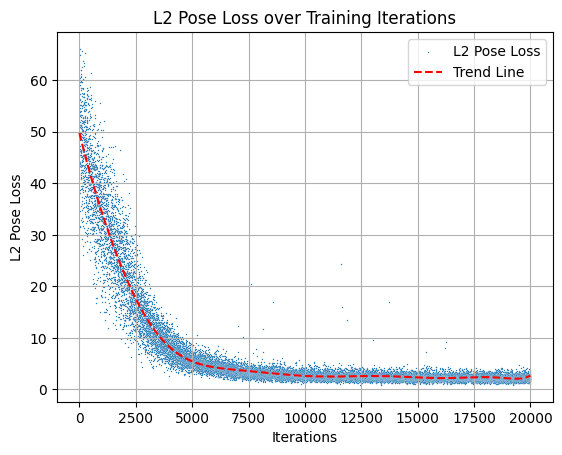

In [111]:
sns.scatterplot(data=df, x=df.index, y='rte', label='L2 Pose Loss', s=1)
# trend line
z = np.polyfit(df.index, df['rte'],10)
p = np.poly1d(z)
plt.plot(df.index, p(df.index), "r--", label='Trend Line')
plt.xlabel('Iterations')
plt.ylabel('L2 Pose Loss')
plt.title('L2 Pose Loss over Training Iterations')
plt.legend()
plt.grid()
print(f"Final 1000 mean L2 : {df.rte[-1000:].mean():.2f}")


# 2nd training

In [112]:
fp  = "metrics/train/2025_12_20_0.csv"
df = pd.read_csv(fp)
df.head()

,epoch,batch,loss,loss_h,loss_c,trans_l2_m,yaw_err_deg
0,0,0,4222.439453,36240.859375,19.945112,12.450598,4.330161
1,0,1,5119.180664,44195.652344,23.320503,12.556104,8.735498
2,0,2,5686.750488,50498.937500,21.228544,13.244211,14.284220
3,0,3,5659.884766,46969.234375,32.098705,12.666931,12.352241
4,0,4,2977.500488,21931.414062,26.145308,6.816884,11.623267


Final 1000 mean loss : 232.0833


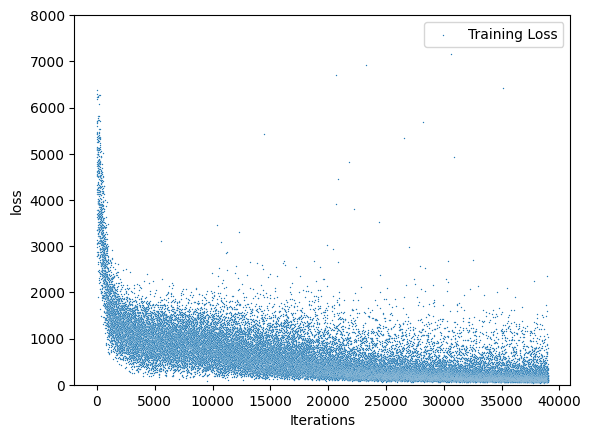

In [113]:
sns.scatterplot(data=df, x=df.index, y='loss', label='Training Loss', s=1)
# sns.lineplot(data=df, x=df.index, y='loss', label='Training Loss')

# sns.scatterplot(data=df, x=df.index, y='loss_c', label='Loss C', s=3)
# sns.scatterplot(data=df, x=df.index, y='loss_h', label='Loss H', s=3)

# trend line
# z = np.polyfit(df.index, df['loss'], 20)
# p = np.poly1d(z)
# plt.plot(df.index, p(df.index), "r--", label='Trend Line')
plt.xlabel('Iterations')
plt.ylim(0, 8000)
# print average loss over last 1000 iterations
print(f"Final 1000 mean loss : {df.loss[-1000:].mean():.4f}")

(0.0, 50.0)

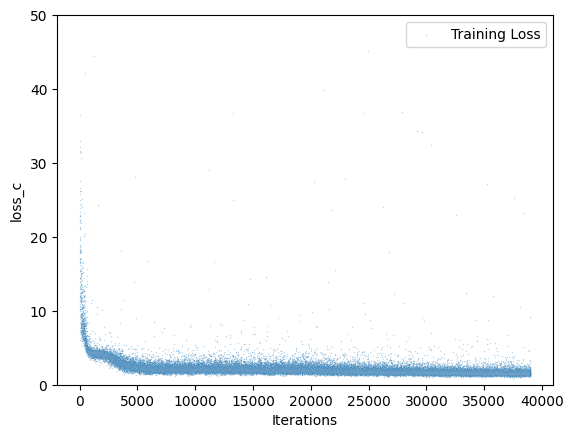

In [114]:
sns.scatterplot(data=df, x=df.index, y='loss_c', label='Training Loss', s=1, alpha=0.3)
# sns.lineplot(data=df, x=df.index, y='loss_c', label='Loss C')

# sns.scatterplot(data=df, x=df.index, y='loss_c', label='Loss C', s=3)
# sns.scatterplot(data=df, x=df.index, y='loss_h', label='Loss H', s=3)

# trend line
# z = np.polyfit(df.index, df['loss_c'], 15)
# p = np.poly1d(z)
# plt.plot(df.index, p(df.index), "r--", label='Trend Line')
plt.xlabel('Iterations')
plt.ylim(0, 50)

/tmp/ipykernel_2419731/3663579962.py:8: RankWarning: Polyfit may be poorly conditioned
  z = np.polyfit(df.index, df['loss_h'], 20)


(0.0, 62000.0)

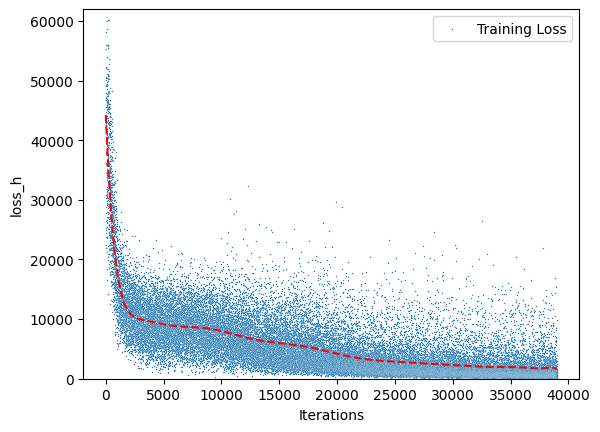

In [115]:
sns.scatterplot(data=df, x=df.index, y='loss_h', label='Training Loss', s=1)
# sns.lineplot(data=df, x=df.index, y='loss_h', label='Loss H')

# sns.scatterplot(data=df, x=df.index, y='loss_c', label='Loss C', s=3)
# sns.scatterplot(data=df, x=df.index, y='loss_h', label='Loss H', s=3)

# trend line
z = np.polyfit(df.index, df['loss_h'], 20)
p = np.poly1d(z)
plt.plot(df.index, p(df.index), "r--", label='Trend Line')
plt.xlabel('Iterations')
plt.ylim(0,62000)

Final 1000 mean L2 : 0.53


(0.0, 16.0)

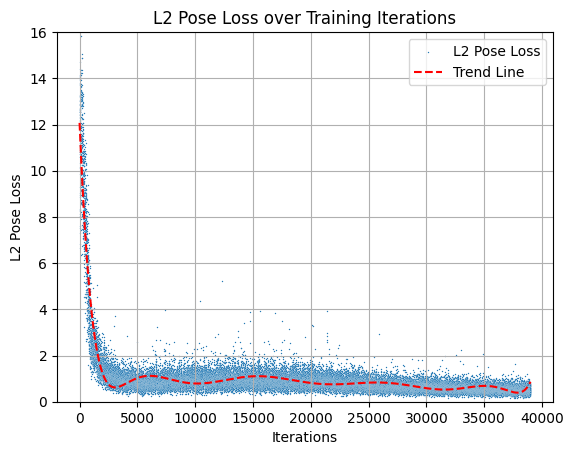

In [116]:
sns.scatterplot(data=df, x=df.index, y='trans_l2_m', label='L2 Pose Loss', s=1)
# sns.lineplot(data=df, x=df.index, y='trans_l2_m', label='Lk2 Pose Loss')
# trend line
z = np.polyfit(df.index, df['trans_l2_m'],10)
p = np.poly1d(z)
plt.plot(df.index, p(df.index), "r--", label='Trend Line')
plt.xlabel('Iterations')
plt.ylabel('L2 Pose Loss')
plt.title('L2 Pose Loss over Training Iterations')
plt.legend()
plt.grid()
print(f"Final 1000 mean L2 : {df.trans_l2_m[-500:].mean():.2f}")
plt.ylim(0,16)


Final 1000 mean Yaw Error : 3.52


(0.0, 18.0)

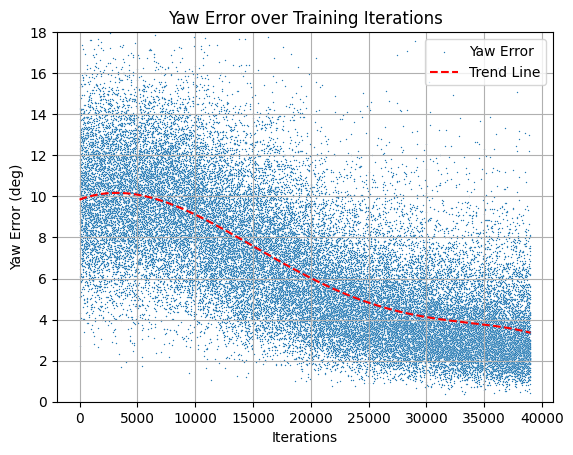

In [117]:
sns.scatterplot(data=df, x=df.index, y='yaw_err_deg', label='Yaw Error', s=1)
# sns.lineplot(data=df, x=df.index, y='yaw_err_deg', label='Yaw Error')
# trend line
z = np.polyfit(df.index, df['yaw_err_deg'],5)
p = np.poly1d(z)
plt.plot(df.index, p(df.index), "r--", label='Trend Line')
plt.xlabel('Iterations')
plt.ylabel('Yaw Error (deg)')
plt.title('Yaw Error over Training Iterations')
plt.legend()
plt.grid()
print(f"Final 1000 mean Yaw Error : {df.yaw_err_deg[-1000:].mean():.2f}")
plt.ylim(0,18)


# $3^{rd}$ Training

In [5]:
# define plotting function for loss, loss_h, loss_c, l2 pose loss, yaw error in one plot
def plot_metric(df, title):
    
    metric = ["loss", "loss_h", "loss_c", "trans_l2_m", "yaw_err_deg"]
    fig, ax = plt.subplots(2, 3, figsize=(12, 6))
    
    for m in metric:
        last_mean = df[m][-500:].mean()
        sns.scatterplot(data=df, x=df.index, y=m, label="Final Mean: {:.4f}".format(last_mean), s=1, ax=ax.flatten()[metric.index(m)])
        # trend line
        z = np.polyfit(df.index, df[m],15)
        p = np.poly1d(z)
        ax.flatten()[metric.index(m)].plot(df.index, p(df.index), "r--", label='Trend Line')
        ax.flatten()[metric.index(m)].set_xlabel('Iterations')
        ax.flatten()[metric.index(m)].set_ylim([0, df[m][0:10].max()*1.1])
        ax.flatten()[metric.index(m)].set_ylabel(m)
        ax.flatten()[metric.index(m)].set_title(m+' over Training Iterations')
        ax.flatten()[metric.index(m)].legend()
        ax.flatten()[metric.index(m)].grid()
    fig.suptitle(title)
    fig.tight_layout()
    fig.show()

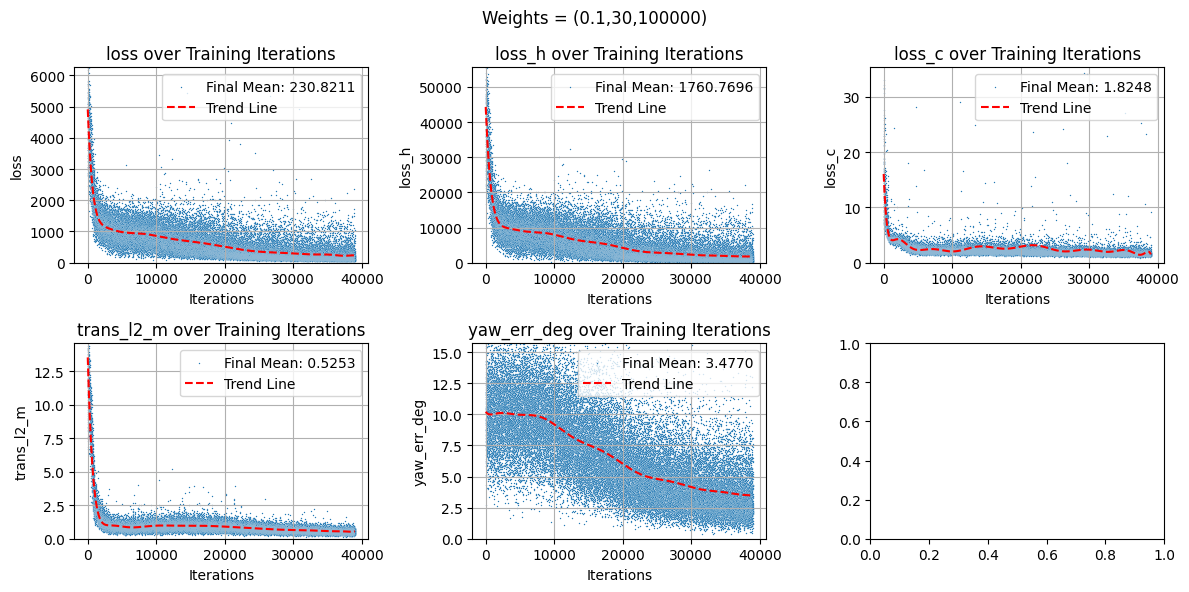

In [119]:
fp  = "metrics/train/2025_12_20_0.csv"
df = pd.read_csv(fp)
plot_metric(df, 'Weights = (0.1,30,100000)')

## Same but longer 

/tmp/ipykernel_3351903/280869166.py:11: RankWarning: Polyfit may be poorly conditioned
  z = np.polyfit(df.index, df[m],15)
/tmp/ipykernel_3351903/280869166.py:11: RankWarning: Polyfit may be poorly conditioned
  z = np.polyfit(df.index, df[m],15)
/tmp/ipykernel_3351903/280869166.py:11: RankWarning: Polyfit may be poorly conditioned
  z = np.polyfit(df.index, df[m],15)
/tmp/ipykernel_3351903/280869166.py:11: RankWarning: Polyfit may be poorly conditioned
  z = np.polyfit(df.index, df[m],15)
/tmp/ipykernel_3351903/280869166.py:11: RankWarning: Polyfit may be poorly conditioned
  z = np.polyfit(df.index, df[m],15)


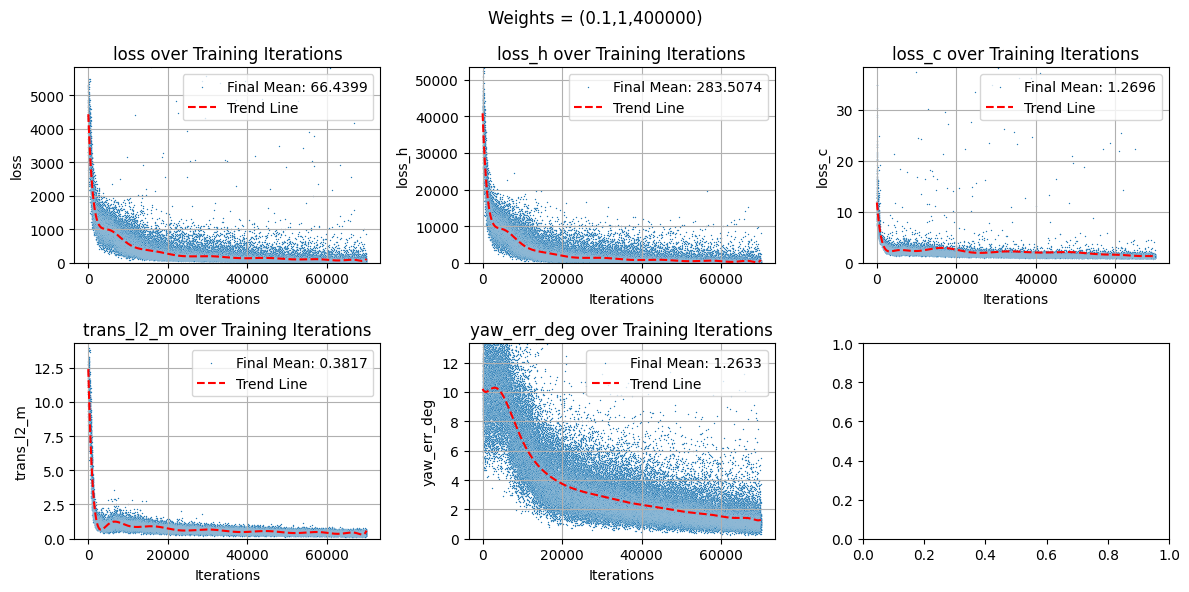

In [6]:
fp = "metrics/train/2025_12_21_2.csv"

df = pd.read_csv(fp)
plot_metric(df, 'Weights = (0.1,1,400000)')

# Same but longgeeerrr 

In [7]:
fp = "metrics/train/2025_12_27_0.csv"

df = pd.read_csv(fp)

# Count how many times we've seen each (epoch, batch) so far
df["_occurrence"] = df.groupby(["epoch", "batch"]).cumcount()

# Split into two dataframes
df_model_1 = df[df["_occurrence"] == 0].drop(columns="_occurrence").reset_index(drop=True)
df_model_2 = df[df["_occurrence"] == 1].drop(columns="_occurrence").reset_index(drop=True)

print(len(df_model_1), len(df_model_2), "/", len(df))


30138 29007 / 59145


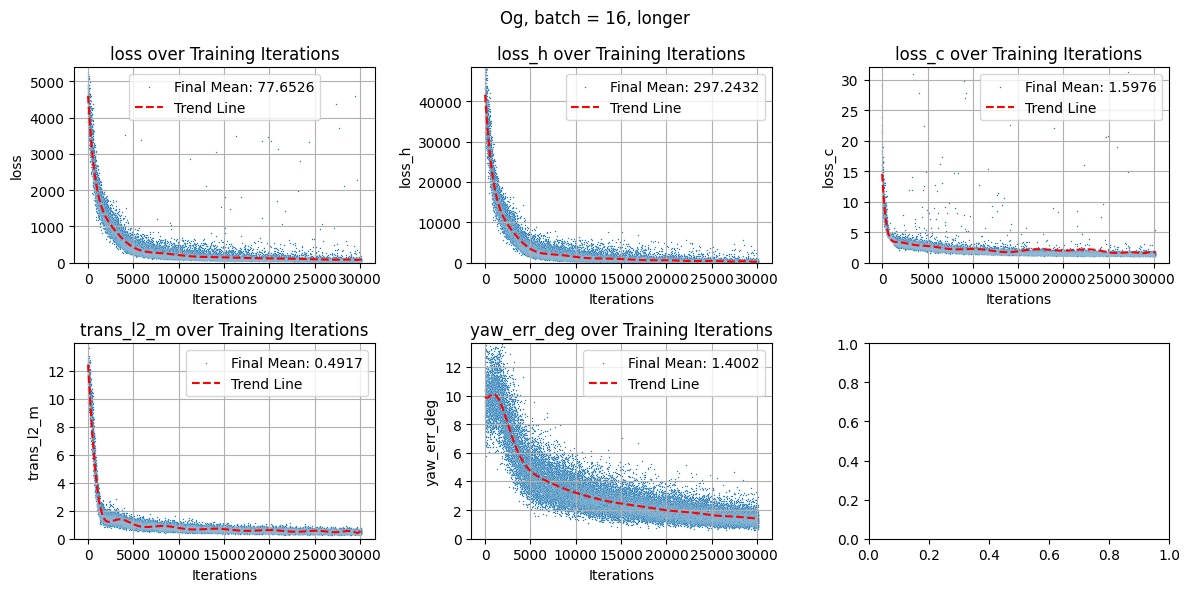

In [8]:
plot_metric(df_model_1, 'Og, batch = 16, longer')

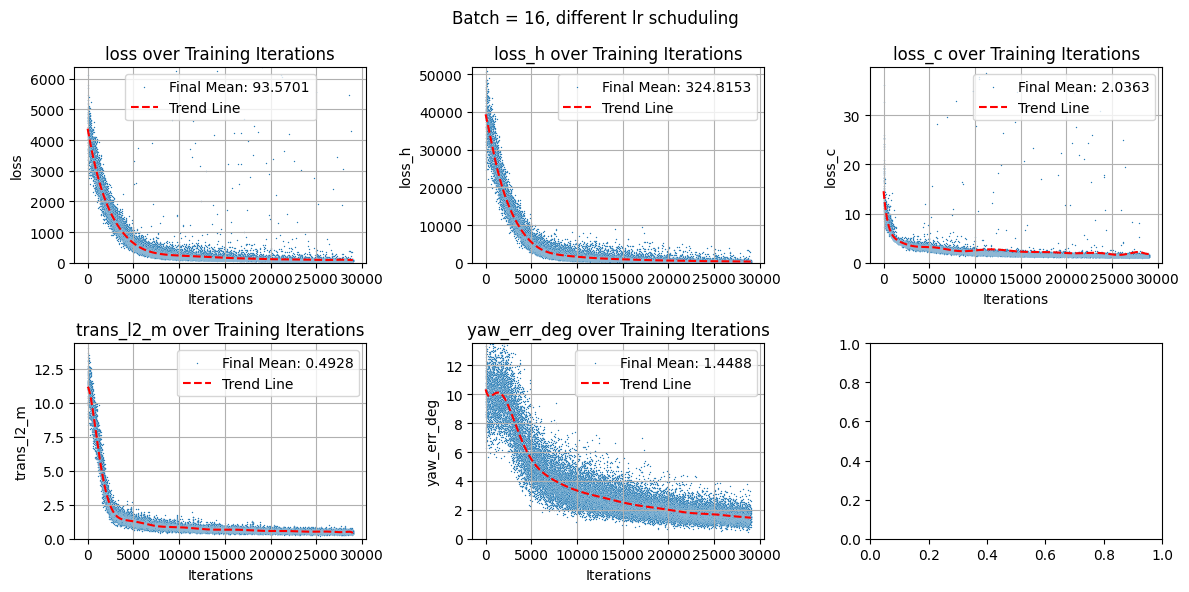

In [9]:
plot_metric(df_model_2, 'Batch = 16, different lr schuduling')

# Validation

In [124]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
fp  = "metrics/val/2025_12_26_2.csv"
df = pd.read_csv(fp)


In [125]:
df.loc[df.meters_l2 > 1.5]

,scene_name,frame_name,iteration,meters_l2,yaw_err_deg,time_ms
509,"[17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17]","[2311, 2312, 2313, 2314, 2315, 2316, 2317, 231...",509,1.514854,0.267418,622.012138


<Axes: xlabel='None', ylabel='meters_l2'>

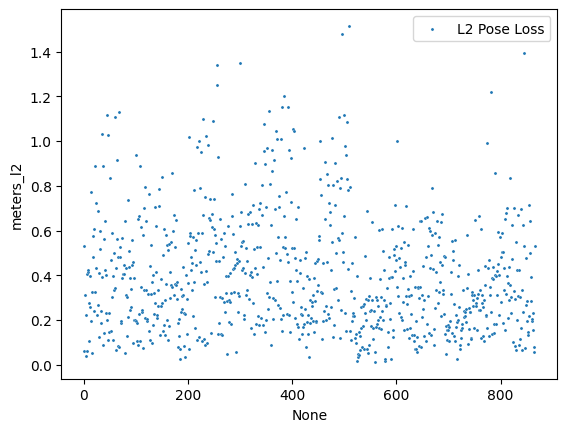

In [126]:
import seaborn as sns
sns.scatterplot(data=df, x=df.index, y='meters_l2', label='L2 Pose Loss', s=5)

<Axes: xlabel='None', ylabel='yaw_err_deg'>

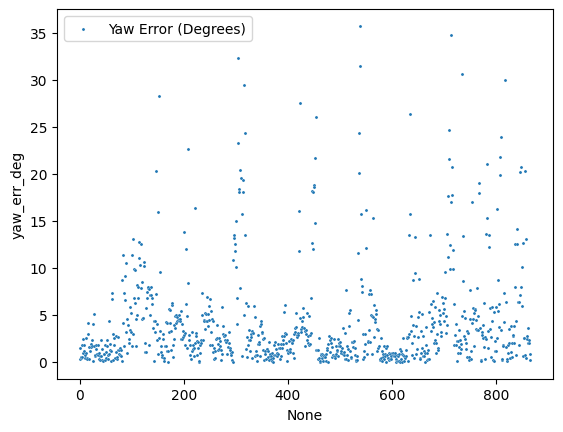

In [127]:
sns.scatterplot(data=df, x=df.index, y='yaw_err_deg', label='Yaw Error (Degrees)', s=5)

In [128]:
df.yaw_err_deg.mean()

4.277883722157902